# Climate Change Modeling using Machine Learning and NLP

-------
### Tools Used:
- Jupyter Notebook
- Python Libraries: Pandas, NumPy, Matplotlib, Seaborn, NLTK, TextBlob, Scikit-learn, Plotly, WordCloud

--------
### Technologies:
- Machine Learning
- Natural Language Processing (NLP)
- Time Series Forecasting
---------

### Datasets:
- NASA Facebook Comments Dataset (Provided)
- Historical Climate Data from sources like NASA, NOAA:
    - CO2 levels
    - Temperature anomalies
    - Sea level rise
    - Precipitation
---------

# PART 1: Understanding Public Sentiment on Climate Change

In [1]:
# 1.1 Load the dataset
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
comments_df = pd.read_csv("climate_nasa.csv")
print("Initial shape:", comments_df.shape)

Initial shape: (522, 5)


In [2]:
# 1.2 Explore structure
print(comments_df.columns)
print(comments_df.head())
print(comments_df.info())
print(comments_df.describe(include='all'))

Index(['date', 'likesCount', 'profileName', 'commentsCount', 'text'], dtype='object')
                       date  likesCount  \
0  2022-09-07T17:12:32.000Z           2   
1  2022-09-08T14:51:13.000Z           0   
2  2022-09-07T17:19:41.000Z           1   
3  2022-09-08T00:51:30.000Z           4   
4  2022-09-07T19:06:20.000Z          16   

                                         profileName  commentsCount  \
0  4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...            NaN   
1  518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...            NaN   
2  d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...            3.0   
3  37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...            NaN   
4  e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...           26.0   

                                                text  
0  Neat comparison I have not heard it before.\n ...  
1  An excellent way to visualise the invisible! T...  
2  Does the CO2/ghg in the troposphere affect the...  
3  excel

In [3]:
# 1.3 Handle missing values
missing_counts = comments_df.isnull().sum()
print("Missing values:\n", missing_counts)

Missing values:
 date               0
likesCount         0
profileName        0
commentsCount    278
text              18
dtype: int64


In [4]:
# 1.4 Drop duplicates
comments_df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", comments_df.shape)

Shape after removing duplicates: (522, 5)


In [5]:
# 1.5 Text Preprocessing
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from textblob import TextBlob

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@w+|\#','', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

# Apply preprocessing
comments_df['cleaned_text'] = comments_df['text'].apply(preprocess)

# Apply sentiment analysis
comments_df['sentiment_score'] = comments_df['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
comments_df['sentiment'] = comments_df['sentiment_score'].apply(
    lambda x: 'Positive' if x > 0 else 'Negative' if x < 0 else 'Neutral'
)

# Check the result
comments_df[['text', 'cleaned_text', 'sentiment_score', 'sentiment']].head()

[nltk_data] Downloading package stopwords to C:\Users\addiction
[nltk_data]     computers\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,cleaned_text,sentiment_score,sentiment
0,Neat comparison I have not heard it before.\n ...,neat comparison heard would say co like disco ...,0.000000,Neutral
1,An excellent way to visualise the invisible! T...,excellent way visualise invisible thanks,0.600000,Positive
2,Does the CO2/ghg in the troposphere affect the...,coghg troposphere affect stratosphere warmer t...,0.000000,Neutral
3,excellent post! I defo feel the difference - o...,excellent post defo feel difference one drink ...,0.142857,Positive
4,"Yes, and carbon dioxide does not harm the Eart...",yes carbon dioxide harm earth like people maki...,-0.375000,Negative


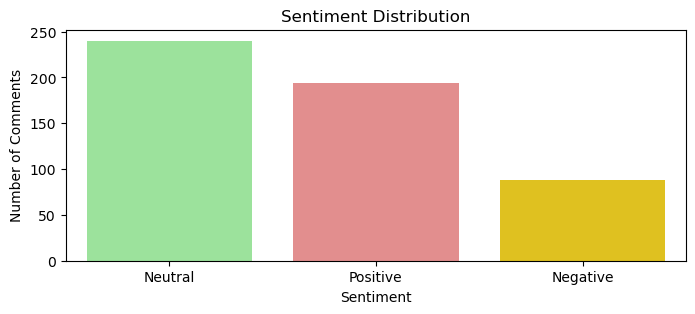

In [7]:
# 1.6 Sentiment Analysis using TextBlob
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
sns.countplot(x='sentiment', data=comments_df, palette=['lightgreen', 'lightcoral', 'gold'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()

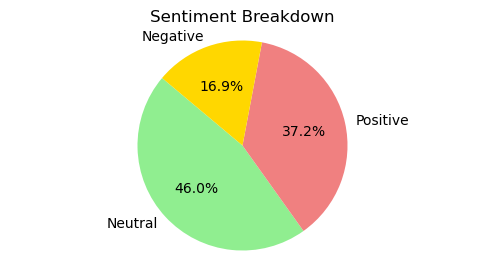

In [15]:
# 1.7 Pie Chart for Sentiment Proportion
sentiment_counts = comments_df['sentiment'].value_counts()
plt.figure(figsize=(6, 3))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightgreen', 'lightcoral', 'gold'])
plt.title('Sentiment Breakdown')
plt.axis('equal')
plt.show()

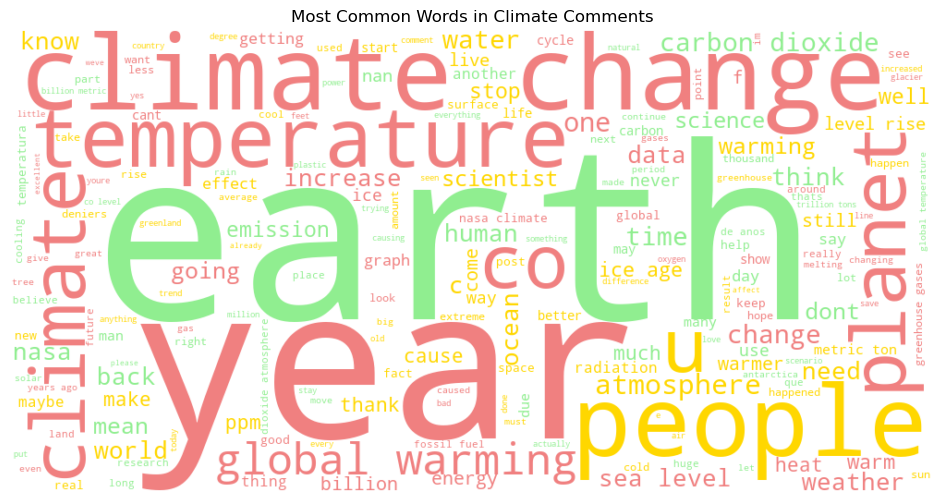

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random

colors = ['lightgreen', 'lightcoral', 'gold']

def my_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(colors)

all_words = ' '.join(comments_df['cleaned_text'].dropna())
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud.recolor(color_func=my_color_func), interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Climate Comments')
plt.show()

In [22]:
# 1.9 Sample Comments by Sentiment
# View random positive, negative, and neutral comments
for sentiment in ['Positive', 'Negative', 'Neutral']:
    print(f"\n--- {sentiment} Examples ---")
    print(comments_df[comments_df['sentiment'] == sentiment]['text'].sample(2, random_state=42).to_string(index=False))


--- Positive Examples ---
                         Good game forfeit at 2024
It's always fun watching dropouts pretend to ar...

--- Negative Examples ---
I'll bet they were talking about a global cooli...
Yes, and carbon dioxide does not harm the Earth...

--- Neutral Examples ---
                        NaN
Before of after I drink it?


In [23]:
comments_df.to_csv("climate_sentiment_analysis_output.csv", index=False)

###  Insights & Conclusion:
- Most comments show "It's always fun watching dropouts pretend...."
- The WordCloud shows frequent usage of terms like "climate", "change", "energy", and "action".
- Sentiment analysis using TextBlob provides a quick but effective overview of public opinion.
